C:\Users\Kusutoglu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


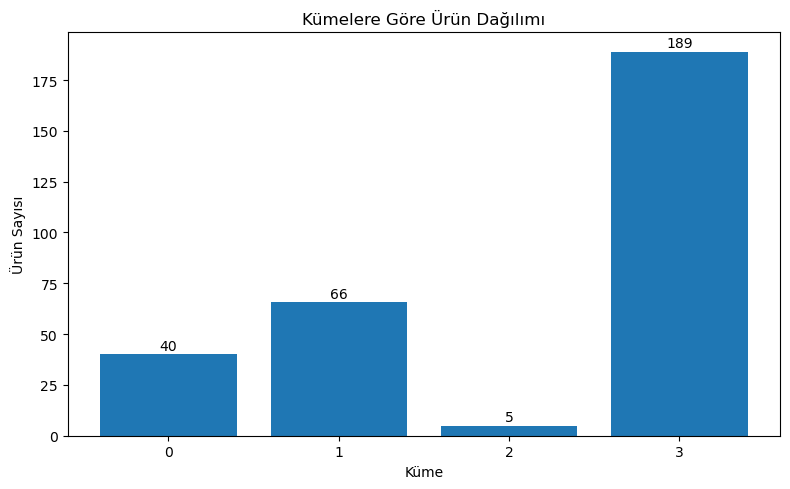


K-Means tamamlandı.
Sonuç dosyası:
kmeans_sonuclari.xlsx

Küme özet dosyası:
kume_ozetleri.xlsx

Grafik:
grafikler/kume_buyuklukleri.png

Küme özetleri:
   kume_no  urun_sayisi  ortalama_fiyat  ortalama_puan  ortalama_ram  \
0        0           40    73025.632000       4.747500     34.600000   
1        1           66    41995.823485       4.700000     22.484848   
2        2            5    58285.392000       0.000000     20.800000   
3        3          189    46488.816825       4.689418     30.243386   

   ortalama_ssd  ortalama_ek_urun  ortalama_pozitiflik  ortalama_risk  \
0   2000.000000          0.150000             0.589210       0.002699   
1   1075.757576          0.939394             0.206061       0.000426   
2   1000.000000          3.000000             0.000000       0.000000   
3   1000.000000          0.148148             0.682072       0.005290   

   ortalama_memnuniyet          kume_etiketi  
0             0.037549        Riskli Ürünler  
1             0.010774   

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

# ==============================
# DOSYALAR
# ==============================

GIRIS_DOSYASI = "analiz_verisi.xlsx"

CIKTI_DOSYASI = "kmeans_sonuclari.xlsx"

KUME_OZET_DOSYASI = "kume_ozetleri.xlsx"

os.makedirs("grafikler", exist_ok=True)

# ==============================
# EXCEL OKU
# ==============================

df = pd.read_excel(GIRIS_DOSYASI)

# ==============================
# KULLANILACAK ÖZELLİKLER
# ==============================

ozellikler = [
    "fiyat_sayisal",
    "puan_sayisal",
    "ram_gb",
    "ssd_gb",
    "ek_urun_sayisi",
    "yorum_memnuniyet_skoru",
    "pozitiflik_orani",
    "risk_orani"
]

ozellikler = [col for col in ozellikler if col in df.columns]

X = df[ozellikler].copy()
X = X.fillna(0)

# ==============================
# STANDARDIZE ET
# ==============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# K-MEANS
# ==============================

K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

df["kume_no"] = kmeans.fit_predict(X_scaled)

# ==============================
# KÜME ÖZETLERİ
# ==============================

kume_ozet = df.groupby("kume_no").agg(
    urun_sayisi=("ürün_adı", "count"),
    ortalama_fiyat=("fiyat_sayisal", "mean"),
    ortalama_puan=("puan_sayisal", "mean"),
    ortalama_ram=("ram_gb", "mean"),
    ortalama_ssd=("ssd_gb", "mean"),
    ortalama_ek_urun=("ek_urun_sayisi", "mean"),
    ortalama_pozitiflik=("pozitiflik_orani", "mean"),
    ortalama_risk=("risk_orani", "mean"),
    ortalama_memnuniyet=("yorum_memnuniyet_skoru", "mean")
).reset_index()

# ==============================
# KÜMELERE İSİM VER
# ==============================

def kume_etiketi(row):

    if row["ortalama_risk"] > kume_ozet["ortalama_risk"].mean():
        return "Riskli Ürünler"

    elif row["ortalama_fiyat"] >= kume_ozet["ortalama_fiyat"].quantile(0.75):
        return "Premium Ürünler"

    elif row["ortalama_fiyat"] <= kume_ozet["ortalama_fiyat"].quantile(0.25):
        return "Ekonomik Ürünler"

    elif row["ortalama_puan"] >= kume_ozet["ortalama_puan"].mean():
        return "Fiyat-Performans Ürünleri"

    else:
        return "Orta Segment Ürünler"


kume_ozet["kume_etiketi"] = kume_ozet.apply(
    kume_etiketi,
    axis=1
)

etiket_sozluk = dict(
    zip(
        kume_ozet["kume_no"],
        kume_ozet["kume_etiketi"]
    )
)

df["kume_etiketi"] = df["kume_no"].map(
    etiket_sozluk
)

# ==============================
# EXCEL KAYDET
# ==============================

df.to_excel(
    CIKTI_DOSYASI,
    index=False
)

kume_ozet.to_excel(
    KUME_OZET_DOSYASI,
    index=False
)

# ==============================
# KÜME BÜYÜKLÜKLERİ GRAFİĞİ
# ==============================

kume_sayilari = (
    df["kume_no"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    kume_sayilari.index.astype(str),
    kume_sayilari.values
)

plt.xlabel("Küme")
plt.ylabel("Ürün Sayısı")
plt.title("Kümelere Göre Ürün Dağılımı")

for i, value in enumerate(kume_sayilari.values):
    plt.text(
        i,
        value + 2,
        str(value),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "grafikler/kume_buyuklukleri.png",
    dpi=300
)

plt.show()

# ==============================
# BİLGİ
# ==============================

print("\nK-Means tamamlandı.")

print("Sonuç dosyası:")
print(CIKTI_DOSYASI)

print("\nKüme özet dosyası:")
print(KUME_OZET_DOSYASI)

print("\nGrafik:")
print("grafikler/kume_buyuklukleri.png")

print("\nKüme özetleri:")

print(kume_ozet)